In [75]:
import pandas as pd
import numpy as np
from glob import glob
import os

In [76]:
files = sorted(
    glob("/content/*.xlsx")
)

print(len(files))

for f in files:
    print(os.path.basename(f))

12
Ecosystem-Statistics-UPI-Upi-statewise-statistics-2025-Apr.xlsx
Ecosystem-Statistics-UPI-Upi-statewise-statistics-2025-Aug.xlsx
Ecosystem-Statistics-UPI-Upi-statewise-statistics-2025-Dec.xlsx
Ecosystem-Statistics-UPI-Upi-statewise-statistics-2025-Jul.xlsx
Ecosystem-Statistics-UPI-Upi-statewise-statistics-2025-Jun.xlsx
Ecosystem-Statistics-UPI-Upi-statewise-statistics-2025-Mar.xlsx
Ecosystem-Statistics-UPI-Upi-statewise-statistics-2025-May.xlsx
Ecosystem-Statistics-UPI-Upi-statewise-statistics-2025-Nov.xlsx
Ecosystem-Statistics-UPI-Upi-statewise-statistics-2025-Oct.xlsx
Ecosystem-Statistics-UPI-Upi-statewise-statistics-2025-Sep.xlsx
Ecosystem-Statistics-UPI-Upi-statewise-statistics-2026-Feb.xlsx
Ecosystem-Statistics-UPI-Upi-statewise-statistics-2026-Jan.xlsx


In [77]:
all_months = []

for file in files:

    month = os.path.basename(file).split("-")[-1].replace(".xlsx","")

    df = pd.read_excel(
        file,
        header=1
    )

    df = df.iloc[:,0:6]

    df.columns = [
        "SrNo",
        "State",
        "Volume",
        "VolContribution",
        "Value",
        "ValContribution"
    ]

    df = df[
        ["State","Volume","Value"]
    ]

    df["Month"] = month

    all_months.append(df)

upi = pd.concat(
    all_months,
    ignore_index=True
)

print(upi.shape)

(444, 4)


In [78]:
upi["State"] = (
    upi["State"]
    .astype(str)
    .str.upper()
    .str.strip()
)

upi["Volume"] = (
    upi["Volume"]
    .astype(str)
    .str.replace(",","")
)

upi["Value"] = (
    upi["Value"]
    .astype(str)
    .str.replace(",","")
)

upi["Volume"] = pd.to_numeric(
    upi["Volume"],
    errors="coerce"
)

upi["Value"] = pd.to_numeric(
    upi["Value"],
    errors="coerce"
)

upi = upi[
    ~upi["State"].str.contains(
        "UNCLASSIFIED",
        na=False
    )
]

In [79]:
print("Rows:", len(upi))
print("States:", upi["State"].nunique())

print("Volume NaNs:", upi["Volume"].isna().sum())
print("Value NaNs:", upi["Value"].isna().sum())

Rows: 432
States: 36
Volume NaNs: 0
Value NaNs: 0


In [80]:
print(len(upi))
print(upi["State"].nunique())
print(upi["Volume"].isna().sum())
print(upi["Value"].isna().sum())

432
36
0
0


In [81]:
population = pd.read_csv("Population.csv")

population = population[
    ["State or Union Territory", "Population (2024)"]
]

population.columns = [
    "State",
    "Population"
]

population["State"] = (
    population["State"]
    .astype(str)
    .str.upper()
    .str.strip()
)

population["Population"] = (
    population["Population"]
    .astype(str)
    .str.replace(",","")
)

population["Population"] = pd.to_numeric(
    population["Population"],
    errors="coerce"
)

population.head()

,State,Population
0,UTTAR PRADESH,241066874
1,BIHAR,128592000
2,MAHARASHTRA,127528000
3,WEST BENGAL,99563000
4,MADHYA PRADESH,87610000


In [82]:
lit_raw = pd.read_csv(
    "literacy.csv",
    header=None
)

literacy = lit_raw.iloc[3:, [0,1]].copy()

literacy.columns = [
    "State",
    "Literacy"
]

literacy["State"] = (
    literacy["State"]
    .astype(str)
    .str.upper()
    .str.replace(
        r"\[.*?\]",
        "",
        regex=True
    )
    .str.strip()
)

literacy["Literacy"] = pd.to_numeric(
    literacy["Literacy"],
    errors="coerce"
)

literacy = literacy.dropna()

literacy.head()

,State,Literacy
3,WEST BENGAL,82.6
4,UTTARAKHAND,83.8
5,UTTAR PRADESH,78.2
6,TRIPURA,93.7
7,TELANGANA,76.9


In [83]:
income_raw = pd.read_excel(
    "income.XLSX",
    header=None
)

income = income_raw.iloc[:, [1, -1]].copy()

income.columns = [
    "State",
    "Income"
]

income["State"] = (
    income["State"]
    .astype(str)
    .str.upper()
    .str.strip()
)

income["Income"] = pd.to_numeric(
    income["Income"],
    errors="coerce"
)

income = income.dropna()

income.head()

,State,Income
5,ANDAMAN & NICOBAR ISLANDS,153904.0
6,ANDHRA PRADESH,120676.0
7,ARUNACHAL PRADESH,124129.0
8,ASSAM,66330.0
9,BIHAR,34045.0


In [84]:
mapping = {
    "ANDAMAN & NICOBAR ISLANDS":
        "ANDAMAN AND NICOBAR ISLANDS",

    "JAMMU & KASHMIR*":
        "JAMMU AND KASHMIR"
}

income["State"] = (
    income["State"]
    .replace(mapping)
)

In [85]:
master = (
    population
    .merge(
        literacy,
        on="State",
        how="inner"
    )
    .merge(
        income,
        on="State",
        how="inner"
    )
)

print(master.shape)

print(
    master["State"].nunique()
)

(32, 4)
32


In [86]:
final_df = upi.merge(
    master,
    on="State",
    how="inner"
)

print(final_df.shape)

print(
    final_df["State"].nunique()
)

(372, 7)
31


In [87]:
final_df["Transactions_Per_Capita"] = (
    final_df["Volume"] * 1_000_000
    / final_df["Population"]
)

final_df["Value_Per_Capita"] = (
    final_df["Value"] * 10_000_000
    / final_df["Population"]
)

final_df.head()

,State,Volume,Value,Month,Population,Literacy,Income,Transactions_Per_Capita,Value_Per_Capita
0,MAHARASHTRA,2382.34,278375.41,Apr,127528000,87.3,163726.0,18.680917,21828.571765
1,KARNATAKA,1263.40,173465.79,Apr,68115000,82.7,169898.0,18.548044,25466.606474
2,UTTAR PRADESH,1206.85,159811.36,Apr,241066874,78.2,54564.0,5.006287,6629.337219
3,TELANGANA,949.72,147127.52,Apr,38272000,76.9,159395.0,24.815008,38442.600334
4,TAMIL NADU,776.90,115363.33,Apr,77089000,85.5,156595.0,10.077962,14964.953495


In [88]:
print(final_df.shape)

print(
    final_df.isna().sum()
)

print(
    final_df["State"].nunique()
)

(372, 9)
State                      0
Volume                     0
Value                      0
Month                      0
Population                 0
Literacy                   0
Income                     0
Transactions_Per_Capita    0
Value_Per_Capita           0
dtype: int64
31


In [89]:
corr = final_df[
[
    "Transactions_Per_Capita",
    "Value_Per_Capita",
    "Population",
    "Literacy",
    "Income"
]
].corr()

corr

,Transactions_Per_Capita,Value_Per_Capita,Population,Literacy,Income
Transactions_Per_Capita,1.000000,0.980476,-0.241846,0.225072,0.818722
Value_Per_Capita,0.980476,1.000000,-0.242078,0.176452,0.790639
Population,-0.241846,-0.242078,1.000000,-0.522102,-0.387131
Literacy,0.225072,0.176452,-0.522102,1.000000,0.403130
Income,0.818722,0.790639,-0.387131,0.403130,1.000000


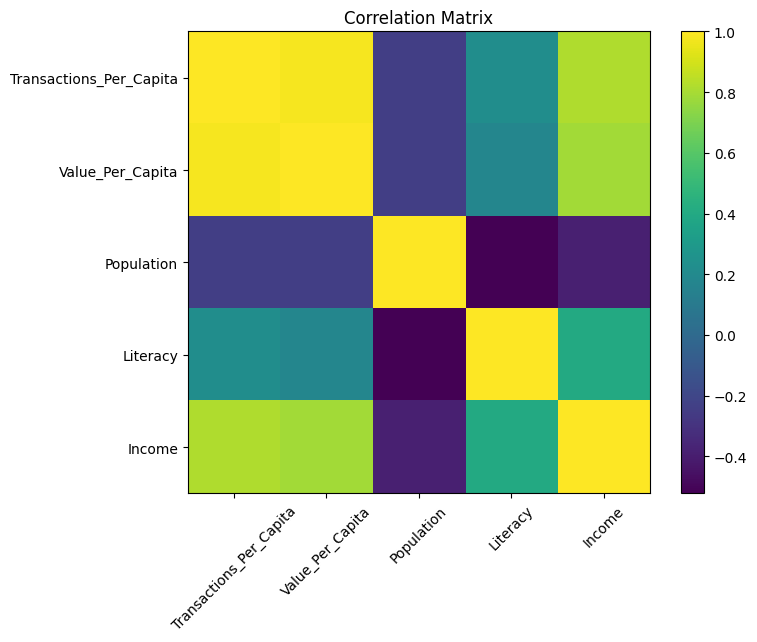

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")
plt.show()

In [91]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

X = final_df[
[
    "Population",
    "Literacy",
    "Income"
]
]

y = final_df["Transactions_Per_Capita"]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

pred = lr.predict(X_test)

print(
    "Linear Regression R²:",
    r2_score(y_test,pred)
)

print(
    "RMSE:",
    mean_squared_error(
        y_test,
        pred
    )**0.5
)

Linear Regression R²: 0.7007571259875895
RMSE: 3.5329481163661085


In [92]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

coef_df.sort_values(
    "Coefficient",
    ascending=False
)

,Feature,Coefficient
2,Income,6.769813e-05
0,Population,3.882303e-09
1,Literacy,-7.943903e-02


In [93]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

pred_rf = rf.predict(X_test)

print(
    "Random Forest R²:",
    r2_score(
        y_test,
        pred_rf
    )
)

Random Forest R²: 0.9608180679876301


In [94]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
2,Income,0.862608
0,Population,0.075594
1,Literacy,0.061798


In [95]:
from sklearn.cluster import KMeans

state_df = (
    final_df.groupby("State")
    [
        [
            "Transactions_Per_Capita",
            "Literacy",
            "Income"
        ]
    ]
    .mean()
)

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

state_df["Cluster"] = (
    kmeans.fit_predict(state_df)
)

state_df.head()

,Transactions_Per_Capita,Literacy,Income,Cluster
State,,,,
ANDHRA PRADESH,10.722035,72.6,120676.0,1
ARUNACHAL PRADESH,13.006557,84.2,124129.0,1
ASSAM,5.817197,87.0,66330.0,0
BIHAR,3.577918,74.3,34045.0,0
CHANDIGARH,21.838294,93.7,252236.0,2


In [96]:
state_df["Cluster"].value_counts()

,count
Cluster,
1,14
0,13
2,3
3,1


In [99]:
internet_df = pd.read_csv("internet.csv")

internet_df.columns = [
    "State",
    "Towers"
]

internet_df["State"] = (
    internet_df["State"]
    .astype(str)
    .str.upper()
    .str.strip()
)

internet_df["Towers"] = (
    internet_df["Towers"]
    .astype(str)
    .str.replace(",","")
)

internet_df["Towers"] = pd.to_numeric(
    internet_df["Towers"],
    errors="coerce"
)

internet_df.head()

,State,Towers
0,ANDHRA PRADESH,58082
1,ASSAM,18793
2,BIHAR,66846
3,DELHI,39283
4,GUJARAT,47126


In [100]:
internet_master = (
    population
    .merge(
        internet_df,
        on="State",
        how="inner"
    )
)

internet_master["Tower_Density"] = (
    internet_master["Towers"]
    /
    internet_master["Population"]
) * 100000

In [101]:
internet_final = final_df.merge(
    internet_master[
        ["State","Tower_Density"]
    ],
    on="State",
    how="inner"
)

print(internet_final.shape)

(192, 10)


In [102]:
internet_final[
[
    "Transactions_Per_Capita",
    "Tower_Density"
]
].corr()

,Transactions_Per_Capita,Tower_Density
Transactions_Per_Capita,1.000000,0.569435
Tower_Density,0.569435,1.000000


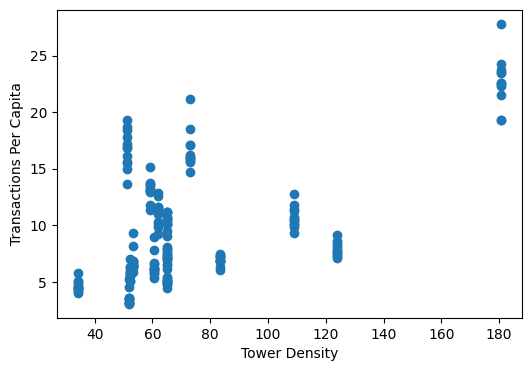

In [103]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.scatter(
    internet_final["Tower_Density"],
    internet_final["Transactions_Per_Capita"]
)

plt.xlabel("Tower Density")
plt.ylabel("Transactions Per Capita")
plt.show()

In [105]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

X = internet_final[
[
    "Population",
    "Literacy",
    "Income",
    "Tower_Density"
]
]

y = internet_final["Transactions_Per_Capita"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print(
    "Random Forest R²:",
    r2_score(y_test, pred_rf)
)

print(
    "RMSE:",
    mean_squared_error(
        y_test,
        pred_rf
    ) ** 0.5
)

Random Forest R²: 0.9672099368006528
RMSE: 0.8787557126227732


In [106]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
2,Income,0.789960
0,Population,0.099187
3,Tower_Density,0.084110
1,Literacy,0.026744
